In [4]:
import numpy as np 
import matplotlib.pyplot as plt
from math import log, exp, sqrt

plt.rcParams.update({
"figure.facecolor": "121212",
"axes.facecolor": "121212",
"axes.edgecolor": "white",
"axes.labelcolor": "white",
"xtick.color": "white",
"ytick.color": "white",
"text.color": "white",
"grid.color": "white",
})

depos ={
1/365 : 0.019040,
7/365 : 0.018950,
1/12 : 0.021770,
3/12 : 0.025120,
6/12 : 0.029880,
1 : 0.034130
}

futures ={
1.129 : 0.032425,
1.378 : 0.030450,
1.627 : 0.028775,
1.877 : 0.027575,
}

swaps = {
2.00 : 0.031997,
3.00 : 0.030250,
4.00 : 0.029181,
5.00 : 0.028635,
6.00 : 0.028318,
7.00 : 0.028173,
8.00 : 0.028180,
9.00 : 0.028305,
10.00 : 0.028505,
11.00 : 0.028692,
12.00 : 0.028839,
15.00 : 0.028895,
20.00 : 0.027624,
25.00 : 0.025948,
30.00 : 0.024459,
40.00 : 0.022278,
50.00 : 0.020573,
}

In [5]:
def interp_df(dfs, T):
    times = sorted(dfs.keys())

    if T in dfs :
        return dfs[T]

    for i in range(len(times)-1):
        t1, t2 = times[i], times[i+1]

        if t1 < T < t2: 
            z1 = -log(dfs[t1])/t1
            z2 = -log(dfs[t2])/t2

            z= z1 + (z2-z1)*(T-t1)/(t2-t1)
            return exp(-z*T)
    t_last = times[-1]
    z_last= -log(dfs[t_last])/t_last

    return exp(-z_last*T)


def bootstrap_depos(depo_data):
    dfs= {}

    for T,r in sorted(depo_data.items()):
        dfs[T] = 1.0 / ( 1.0 + r*T )

    return dfs

def bootstrap_futures(dfs, futures_data):
    known_times = sorted(dfs.keys())

    last_T = known_times[-1]
    last_df = dfs[last_T]

    for T,r in sorted(futures_data.items()):
        df= last_df / ( 1 + r*(T-last_T))
        dfs[T] = df
        last_T = T
        last_df = df
    return dfs

def bootstrap_swaps(dfs, swap_data):

    for T,swap_rate in sorted(swap_data.items()):
        payment_dates = np.arange(1.0, T, 1.0)
        fixed_leg = 0.0

        for t in payment_dates:
            fixed_leg += interp_df(dfs, t)
        df_T = (1-swap_rate*fixed_leg)/(1+ swap_rate)
        dfs[T] = df_T

    return dfs

In [6]:
def bond_pricer(notional, maturity, coupon, payment_frequency, DFs):

    coupon_dates = np.arange(1/payment_frequency, maturity + 1/payment_frequency, payment_frequency)
    bond_dfs = [interp_df(DFs, t) for t in coupon_dates]
    Price = 0
    for t in range(len(coupon_dates)):
        if t == len(coupon_dates)-1 : 
            Price += (1 + coupon*payment_frequency)*notional*bond_dfs[t]
        else :
            Price +=  coupon*payment_frequency*notional*bond_dfs[t]

    return Price


def parallel_shock_RF(rates, times, shock):

    shocked_rates = [z + shock for z in rates]
    shocked_DFs = {
        t : exp(-z*t)
        for z,t in zip(shocked_rates, times)
    }

    return shocked_rates, shocked_DFs

def swap_rate_calculator(swap_maturity, payment_frequency, dfs):
    settle_dates =  np.arange(1/payment_frequency, swap_maturity + 1/payment_frequency, payment_frequency)
    swap_DFs = [interp_df(dfs,t) for t in settle_dates]
    BPV = np.sum([swap_DFs[t]*1/payment_frequency for t in range(len(settle_dates))])
    swap_rate = (1-swap_DFs[-1])/BPV
    return swap_rate

In [7]:
dfs= bootstrap_depos(depos)
dfs= bootstrap_futures(dfs,futures)
dfs= bootstrap_swaps(dfs,swaps)

times = sorted(dfs.keys())

zero_rates= [-log(dfs[t])/t for t in times]

In [10]:
M1 = 10
C1 = 0.04
N1 = 1e8
F1 = 2

### Bond Price
Price = bond_pricer(N1,M1,C1,F1,dfs)
print(f"Bond Price is : €{Price:.2f}")

### Shocked ZC Bond Pricing

Shock = 0.0100 # 100 basis point

Shocked_zrates , shocked_DFs = parallel_shock_RF(zero_rates, times , Shock)
Shocked_Price = bond_pricer(N1,M1,C1,F1, shocked_DFs)

print(f"1bp Shocked Bond Price is : €{Shocked_Price:.2f}")

PL = Shocked_Price - Price
print(f"PL =  €{PL:.2f}")

Bond Price is : €114306108.07
1bp Shocked Bond Price is : €106403336.73
PL =  €-7902771.33


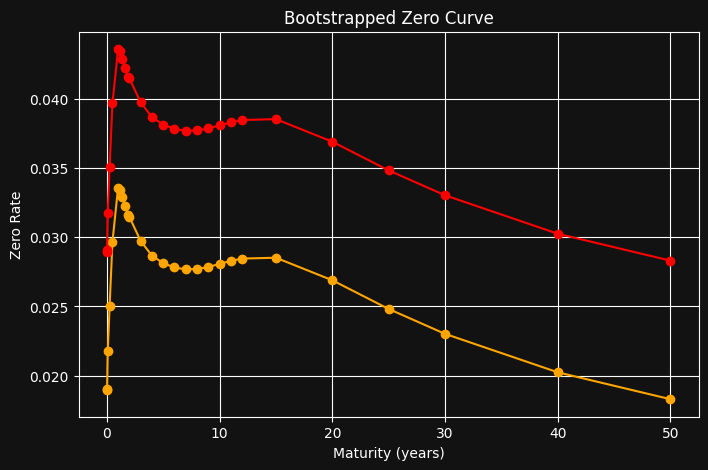

In [11]:
plt.figure(figsize=(8,5))
plt.plot(times, zero_rates, marker="o", color="orange")
plt.plot(times, Shocked_zrates, marker="o", color="red")
plt.title("Bootstrapped Zero Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero Rate")
plt.grid()
plt.show()
